In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

from xgboost import XGBClassifier

In [2]:
rfm = pd.read_csv(
    "../data/features/customer_segments.csv"
)

rfm.head()

,CustomerID,Recency,Frequency,Monetary,Cluster,Segment
0,12346.0,165,11,372.86,3,Loyal Customers
1,12347.0,3,2,1323.32,0,New Customers
2,12348.0,74,1,222.16,2,Lost Customers
3,12349.0,43,3,2671.14,3,Loyal Customers
4,12351.0,11,1,300.93,0,New Customers


In [3]:
rfm = pd.read_csv(
    "../data/features/customer_segments.csv"
)

rfm.head()

,CustomerID,Recency,Frequency,Monetary,Cluster,Segment
0,12346.0,165,11,372.86,3,Loyal Customers
1,12347.0,3,2,1323.32,0,New Customers
2,12348.0,74,1,222.16,2,Lost Customers
3,12349.0,43,3,2671.14,3,Loyal Customers
4,12351.0,11,1,300.93,0,New Customers


In [4]:
rfm.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4312 entries, 0 to 4311
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   CustomerID  4312 non-null   float64
 1   Recency     4312 non-null   int64  
 2   Frequency   4312 non-null   int64  
 3   Monetary    4312 non-null   float64
 4   Cluster     4312 non-null   int64  
 5   Segment     4312 non-null   object 
dtypes: float64(2), int64(3), object(1)
memory usage: 202.3+ KB


Recency > 90 days
=
Churned Customer

In [5]:
rfm["Churn"] = np.where(
    rfm["Recency"] > 90,
    1,
    0
)

In [6]:
rfm["Churn"].value_counts()

Churn
0    2877
1    1435
Name: count, dtype: int64

In [7]:
rfm["Churn"].value_counts(normalize=True)

Churn
0    0.667208
1    0.332792
Name: proportion, dtype: float64

In [8]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

rfm["SegmentEncoded"] = encoder.fit_transform(
    rfm["Segment"]
)

In [9]:
rfm.head()

,CustomerID,Recency,Frequency,Monetary,Cluster,Segment,Churn,SegmentEncoded
0,12346.0,165,11,372.86,3,Loyal Customers,1,1
1,12347.0,3,2,1323.32,0,New Customers,0,2
2,12348.0,74,1,222.16,2,Lost Customers,0,0
3,12349.0,43,3,2671.14,3,Loyal Customers,0,1
4,12351.0,11,1,300.93,0,New Customers,0,2


In [10]:
X = rfm[
    [
        "Recency",
        "Frequency",
        "Monetary",
        "Cluster",
        "SegmentEncoded"
    ]
]

y = rfm["Churn"]

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [12]:
model = XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    random_state=42
)

model.fit(X_train, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

In [13]:
y_pred = model.predict(X_test)

y_prob = model.predict_proba(X_test)[:,1]

In [14]:
print(
    "Accuracy:",
    accuracy_score(y_test, y_pred)
)

print(
    "Precision:",
    precision_score(y_test, y_pred)
)

print(
    "Recall:",
    recall_score(y_test, y_pred)
)

print(
    "F1:",
    f1_score(y_test, y_pred)
)

print(
    "ROC AUC:",
    roc_auc_score(y_test, y_prob)
)

Accuracy: 0.9953650057937428
Precision: 0.9964912280701754
Recall: 0.9895470383275261
F1: 0.993006993006993
ROC AUC: 0.9999727787456446


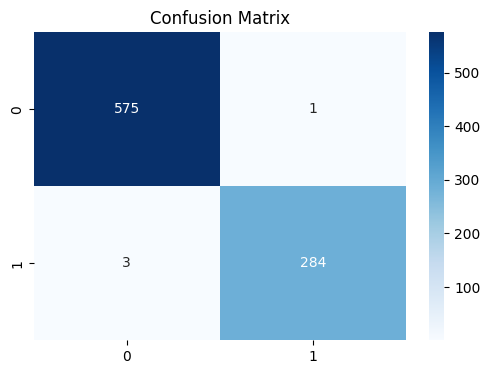

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(
    y_test,
    y_pred
)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Confusion Matrix")

plt.show()

In [16]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
})

importance.sort_values(
    by="Importance",
    ascending=False
)

,Feature,Importance
0,Recency,0.995105
4,SegmentEncoded,0.002883
2,Monetary,0.002011
1,Frequency,0.000000
3,Cluster,0.000000


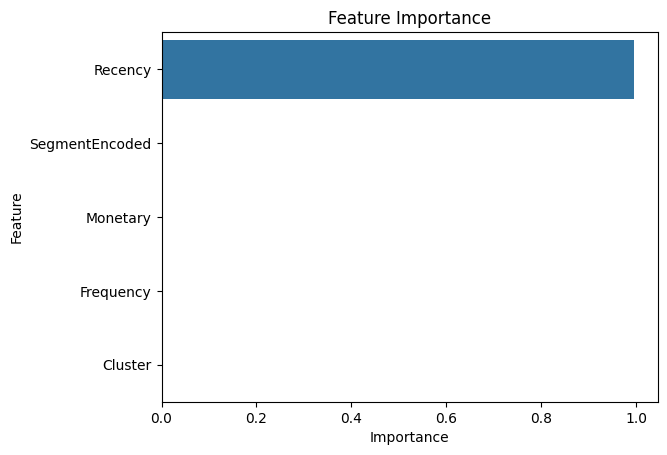

In [17]:
sns.barplot(
    data=importance.sort_values(
        by="Importance",
        ascending=False
    ),
    x="Importance",
    y="Feature"
)

plt.title(
    "Feature Importance"
)

plt.show()

In [19]:
import joblib

joblib.dump(
    model,
    "../models/churn/xgboost_churn.pkl"
)

['../models/churn/xgboost_churn.pkl']

In [20]:
rfm["Churn"].value_counts()

Churn
0    2877
1    1435
Name: count, dtype: int64

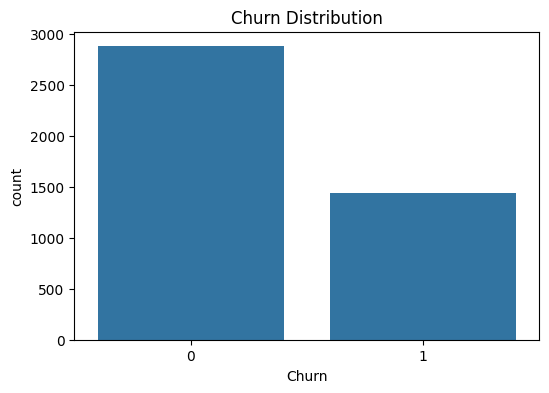

In [21]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

sns.countplot(
    x=rfm["Churn"]
)

plt.title("Churn Distribution")

plt.show()

### Churn Definition

Since the Online Retail II dataset does not contain an explicit churn label,
a business rule was applied.

Customers with Recency > 90 days were considered churned.

Customers with Recency ≤ 90 days were considered active.

This generated:
- Active Customers: 2877
- Churned Customers: 1435

In [22]:
print(classification_report(
    y_test,
    y_pred
))

              precision    recall  f1-score   support

           0       0.99      1.00      1.00       576
           1       1.00      0.99      0.99       287

    accuracy                           1.00       863
   macro avg       1.00      0.99      0.99       863
weighted avg       1.00      1.00      1.00       863



In [23]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
})

importance.sort_values(
    by="Importance",
    ascending=False
)

,Feature,Importance
0,Recency,0.995105
4,SegmentEncoded,0.002883
2,Monetary,0.002011
1,Frequency,0.000000
3,Cluster,0.000000


In [24]:
import joblib

joblib.dump(
    model,
    "../models/churn/xgboost_churn.pkl"
)

['../models/churn/xgboost_churn.pkl']